In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
ocnfrac = xr.open_dataset('/glade/work/acruz/E3SMv2LE/E3SMv2le_OCNFRACs.nc')
Ts = xr.open_dataset('/glade/work/acruz/E3SMv2LE/E3SMv2le_Ts.nc')

In [3]:
ocnfrac

<xarray.Dataset> Size: 9GB
Dimensions:  (lat: 192, lon: 288, time: 1980, member: 21)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: member
Data variables:
    OCNFRAC  (member, time, lat, lon) float32 9GB ...

In [4]:
Ts

<xarray.Dataset> Size: 9GB
Dimensions:  (lat: 192, lon: 288, time: 1980, member: 21)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    lev      float64 8B ...
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: member
Data variables:
    T        (member, time, lat, lon) float32 9GB ...

In [12]:
SSTs = Ts.where(ocnfrac.OCNFRAC==1)
SSTs

<xarray.Dataset> Size: 9GB
Dimensions:  (member: 21, time: 1980, lat: 192, lon: 288)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    lev      float64 8B ...
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: member
Data variables:
    T        (member, time, lat, lon) float32 9GB nan nan nan ... nan nan nan

In [15]:
SSTs = SSTs - 272.15

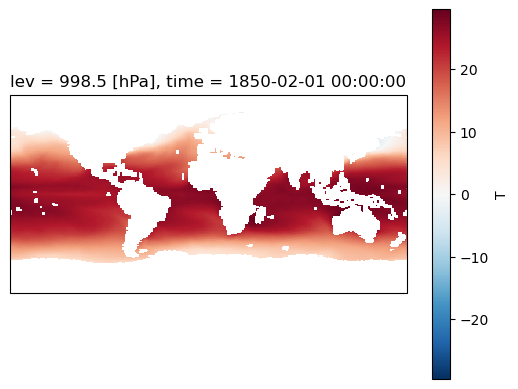

In [16]:
p = SSTs.T.isel(member=0, time=0).plot(subplot_kws=dict(projection=ccrs.PlateCarree()),
    transform=ccrs.PlateCarree(),)

In [18]:
SSTs.to_netcdf('/glade/work/acruz/E3SMv2LE/E3SMv2_hist_SSTs.nc')